In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'axes.labelsize' : 'large',
                     'pdf.fonttype' : 42
                    }) 

import pickle
import re

from scipy import stats
import gseapy as gp
from itertools import combinations

In [2]:
!pwd

/project/GCRB/Hon_lab/s223695/Data_project/TFperturb_edist_additonal/dropout_analysis


In [3]:
sgRNA_count_tf_full_file = "/project/GCRB/Hon_lab/s215194/Single_Cell/TF_perturbseq_full/_all_lanes_combined/aggr_dataframe/aggr_combined_df_full.pkl"
sgRNA_count_tf_full_df = pd.read_pickle(sgRNA_count_tf_full_file)
sgRNA_count_tf_full_df = pd.DataFrame(np.sum((sgRNA_count_tf_full_df>0),axis=1))

In [4]:
sgRNA_count_tf_full_df.columns = ["count_full_data"]
sgRNA_count_tf_full_df

,count_full_data
ADNP2_-_77867536.23-P1P2-1,68
ADNP2_-_77867536.23-P1P2-2,406
ADNP2_-_77867648.23-P1P2-2,74
ADNP_-_49547603.23-P1P2-2,60
AEBP1_+_44143999.23-P1P2-1,195
...,...
non-targeting_03758,109
non-targeting_03761,188
non-targeting_03762,48
non-targeting_03768,39


In [5]:
sgRNA_count_tf_full_df[sgRNA_count_tf_full_df.index.str.startswith("OR")]

,count_full_data
OR10G4-1,72
OR10G4-3,122
OR10G4-4,86
OR10G4-5,34
OR10G4-6,133
...,...
ORAI1-1,23
ORAI1-2,314
ORAI1-3,230
ORAI1-5,219


In [6]:
sgRNA_count_tf_full_dict = sgRNA_count_tf_full_df.to_dict()["count_full_data"]

In [7]:
sgRNA_count_tf_full_df.shape

(11638, 1)

In [8]:
D0_original_df = pd.read_csv("./D0_original_count.csv",index_col=0)
D7_original_df = pd.read_csv("./D7_original_count.csv",index_col=0)
D0_repA_df = pd.read_csv("./D0_repA_count.csv",index_col=0)
D0_repB_df = pd.read_csv("./D0_repB_count.csv",index_col=0)

In [9]:
D0_original_df.columns=["photospacer","count_D0_original"]
D7_original_df.columns=["photospacer","count_D7_original"]
D0_repA_df.columns=["photospacer","count_D0_repA"]
D0_repB_df.columns=["photospacer","count_D0_repB"]

In [10]:
sgRNA_count_df = pd.concat([D0_original_df.iloc[:,1],
                            D0_repA_df.iloc[:,1],
                            D0_repB_df.iloc[:,1],
                            D7_original_df.iloc[:,1]],
                           axis=1)

In [11]:
#change the name of OR gene
index_tmp = sgRNA_count_df.index.tolist()
index_tmp_after_edit = index_tmp
OR_count_dict = {}

for i,df_index in enumerate(index_tmp):
    if df_index.startswith("OR"):
        if df_index in OR_count_dict.keys():
            index_tmp_after_edit[i] = df_index+"-"+str(OR_count_dict[df_index]+1)
            OR_count_dict[df_index] = OR_count_dict[df_index]+1
        else:
            index_tmp_after_edit[i] = df_index+"-1"
            OR_count_dict[df_index] = 1
sgRNA_count_df.index = index_tmp_after_edit

In [12]:
# One index is named wrong
mis_index = np.where(sgRNA_count_df.index=="chrX:21856386-21856404(-);chrX:21856256-21856677;YY2_P1P2;TF;AGGAAGGGGCGAGCTGCAG")[0][0]
print("before",sgRNA_count_df.index[mis_index])

index_tmp = sgRNA_count_df.index.tolist()
index_tmp[mis_index] = "chrX:21856367-21856386(-);chrX:21856256-21856677;YY2_P1P2;TF;AGGAAGGGGCGAGCTGCAG"
sgRNA_count_df.index = index_tmp
print("after",sgRNA_count_df.index[mis_index])

before chrX:21856386-21856404(-);chrX:21856256-21856677;YY2_P1P2;TF;AGGAAGGGGCGAGCTGCAG
after chrX:21856367-21856386(-);chrX:21856256-21856677;YY2_P1P2;TF;AGGAAGGGGCGAGCTGCAG


### Merge scRNA-Seq count and oligo_count

In [13]:
annotation_file = "/project/GCRB/Hon_lab/s223695/Data_project/TFperturb_edist_additonal/full_annotation_df2.csv"
annotation_df = pd.read_csv(annotation_file,index_col=0)

In [14]:
def convert_name_from_oligo(oligo_name):
    if re.match("^chr[0-9XYM]+:",oligo_name)!=None:
        gRNA_loc,region_loc,transcript_name,source_info,spacer_seq = re.split(";",oligo_name)
        guide_chr, guide_start_end, strand = [x for x in re.split("[:()]",gRNA_loc) if not x.strip() == '']
        guide_start,guide_end = re.split("-",guide_start_end)
        target_row = annotation_df[(annotation_df["guide_chr"]==guide_chr) &
                                   (annotation_df["guide_start"]==int(guide_start))
                                  ]
        if target_row.shape[0] == 0:
            return "Not_exist"
        else:
            return target_row["protospacer_target"].values[0]
    else:
        return oligo_name

In [15]:
sgRNA_count_df["scRNA_guide_name"] = [convert_name_from_oligo(x) for x in sgRNA_count_df.index]

In [16]:
sgRNA_count_df[sgRNA_count_df["scRNA_guide_name"]=="Not_exist"]

,count_D0_original,count_D0_repA,count_D0_repB,count_D7_original,scRNA_guide_name


In [17]:
scRNA_count_list = []
for gRNA_name in sgRNA_count_df["scRNA_guide_name"].values:
    if gRNA_name in sgRNA_count_tf_full_dict.keys():
        scRNA_count_list.append(sgRNA_count_tf_full_dict[gRNA_name])
    else:
        scRNA_count_list.append(0)
sgRNA_count_df["scRNA_count"] = scRNA_count_list

In [18]:
sgRNA_count_df = sgRNA_count_df.set_index("scRNA_guide_name")

In [19]:
sgRNA_count_df.sum(axis=0)

count_D0_original    1363282
count_D0_repA        3832656
count_D0_repB        4150422
count_D7_original    3031442
scRNA_count          1411093
dtype: int64

In [20]:
sgRNA_count_df_CPM = sgRNA_count_df.apply(lambda x:x/np.sum(x)*1000000,axis=0)

In [21]:
sgRNA_count_df_CPM["count_D0_mean"] = (sgRNA_count_df_CPM["count_D0_repA"]+ \
                                       sgRNA_count_df_CPM["count_D0_repB"])/2

In [22]:
np.sum(sgRNA_count_df_CPM,axis=0)

count_D0_original    1000000.0
count_D0_repA        1000000.0
count_D0_repB        1000000.0
count_D7_original    1000000.0
scRNA_count          1000000.0
count_D0_mean        1000000.0
dtype: float64

### analysis 1: where dropout happens?

In [23]:
sgRNA_count_df_CPM[(sgRNA_count_df_CPM["count_D0_mean"]>5)]

,count_D0_original,count_D0_repA,count_D0_repB,count_D7_original,scRNA_count,count_D0_mean
scRNA_guide_name,,,,,,
AATF_-_35306286.23-P1P2-1,0.000000,0.000000,14.456361,0.000000,0.000000,7.228181
AATF_-_35306333.23-P1P2-2,0.000000,27.396145,18.070452,13.195041,0.000000,22.733298
AATF_-_35306351.23-P1P2-1,0.000000,7.827470,2.409394,0.000000,0.000000,5.118432
ADNP2_-_77867536.23-P1P2-1,55.014296,56.096869,28.912723,14.844421,48.189595,42.504796
ADNP2_-_77867536.23-P1P2-2,58.681916,173.508919,144.563613,192.977467,287.720228,159.036266
...,...,...,...,...,...,...
DNAJC19 sgRNA main,47.679057,103.061689,102.399226,77.520863,0.000000,102.730457
MALAT1,256.733383,36499.231864,29935.269233,118.755365,38.976878,33217.250549
NGFRAP1,1321.076637,4390.427943,3968.271178,846.131973,1332.300564,4179.349561


PearsonRResult(statistic=0.9917485310347174, pvalue=0.0)
SignificanceResult(statistic=0.8078203802810239, pvalue=0.0)


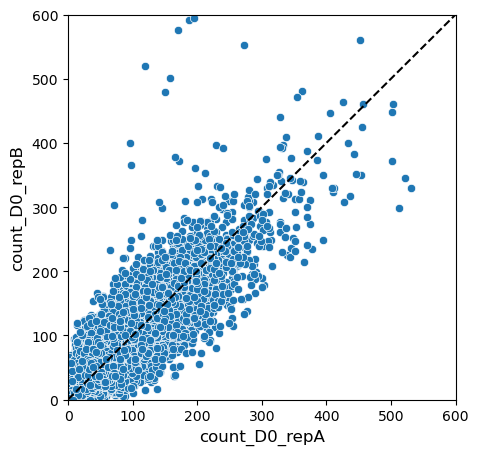

In [24]:
print(stats.pearsonr(sgRNA_count_df_CPM["count_D0_repA"], sgRNA_count_df_CPM["count_D0_repB"]))
print(stats.spearmanr(sgRNA_count_df_CPM["count_D0_repA"], sgRNA_count_df_CPM["count_D0_repB"]))

fig,ax = plt.subplots(figsize=(5,5))
ax.set_xlim(0,600)
ax.set_ylim(0,600)
sns.scatterplot(data=sgRNA_count_df_CPM,x="count_D0_repA",y="count_D0_repB")
ax.plot((0,3000),(0,3000),linestyle="--",c="black")

PearsonRResult(statistic=0.19059514919188014, pvalue=3.188550266008589e-116)
SignificanceResult(statistic=0.7809411678108431, pvalue=0.0)


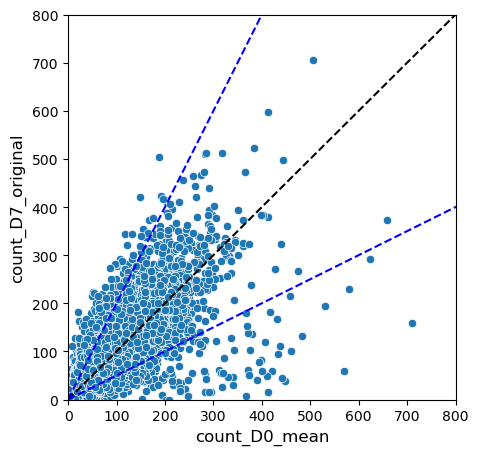

In [25]:
print(stats.pearsonr(sgRNA_count_df_CPM["count_D0_mean"], sgRNA_count_df_CPM["count_D7_original"]))
print(stats.spearmanr(sgRNA_count_df_CPM["count_D0_mean"], sgRNA_count_df_CPM["count_D7_original"]))

fig,ax = plt.subplots(figsize=(5,5))
ax.set_xlim(0,800)
ax.set_ylim(0,800)
sns.scatterplot(data=sgRNA_count_df_CPM,x="count_D0_mean",y="count_D7_original")
ax.plot((0,1000),(0,1000),linestyle="--",c="black")
ax.plot((0,1000),(0,500),linestyle="--",c="blue")
ax.plot((0,500),(0,1000),linestyle="--",c="blue")

### Find good cutoff

In [29]:
def extract_gene_name(entry):
    if entry.startswith('OR'):
        return entry.split("-")[0]
    else:
        return entry.split("_")[0]
    
def extract_transcript_name(entry):
    gene_name = ""
    transcript_name = ""
    if entry.startswith('OR'):
        gene_name = entry.split("-")[0]
    else:
        gene_name = entry.split('_')[0]
        transcript_name = entry.split('-')[-2:][0]
    if len(entry.split('_')) <3:
        transcript_name = gene_name
    else:
        transcript_name = gene_name + '_' + transcript_name
    return transcript_name

In [30]:
sgRNA_count_df_CPM["is_NC"] = [(re.match("^OR[A-Z0-9]+-[0-9]",x)!=None) or \
                               (x.startswith("non-targeting_")) \
                               for x in sgRNA_count_df_CPM.index]
sgRNA_count_df_CPM["target_gene"] = [extract_gene_name(x) for x in sgRNA_count_df_CPM.index]

In [31]:
NC_count = np.sum(sgRNA_count_df_CPM["is_NC"])
Test_count = np.sum(~sgRNA_count_df_CPM["is_NC"])
percent = round(NC_count / (NC_count+Test_count),3)
print("All", NC_count,Test_count,percent)   
print("drop off")
for cutoff in np.arange(1,5,0.5):
    enrichment = sgRNA_count_df_CPM["count_D7_original"]/sgRNA_count_df_CPM["count_D0_mean"]
    sgRNA_enrichment_tmp = sgRNA_count_df_CPM[enrichment<(1/cutoff)]
    
    NC_count = np.sum(sgRNA_enrichment_tmp["is_NC"])
    Test_count = np.sum(~sgRNA_enrichment_tmp["is_NC"])
    percent = round(NC_count / (NC_count+Test_count),3)
    
    print(round(cutoff,3), NC_count,Test_count,percent)

print("proliferate")    
for cutoff in np.arange(1,5,0.5):
    enrichment = sgRNA_count_df_CPM["count_D7_original"]/sgRNA_count_df_CPM["count_D0_mean"]
    sgRNA_enrichment_tmp = sgRNA_count_df_CPM[enrichment>cutoff]
    
    NC_count = np.sum(sgRNA_enrichment_tmp["is_NC"])
    Test_count = np.sum(~sgRNA_enrichment_tmp["is_NC"])
    percent = round(NC_count / (NC_count+Test_count),3)
    
    print(round(cutoff,3), NC_count,Test_count,percent)

All 1198 12997 0.084
drop off
1.0 558 6490 0.079
1.5 280 3350 0.077
2.0 168 2058 0.075
2.5 111 1507 0.069
3.0 76 1213 0.059
3.5 56 1030 0.052
4.0 46 918 0.048
4.5 41 827 0.047
proliferate
1.0 640 6343 0.092
1.5 313 2816 0.1
2.0 143 1376 0.094
2.5 68 776 0.081
3.0 35 456 0.071
3.5 20 321 0.059
4.0 11 248 0.042
4.5 7 212 0.032


In [32]:
cutoff_fc = 4
cutoff_D0_count = 20

In [33]:
sgRNA_count_df_CPM.head()

,count_D0_original,count_D0_repA,count_D0_repB,count_D7_original,scRNA_count,count_D0_mean,is_NC,target_gene
scRNA_guide_name,,,,,,,,
AATF_-_35306286.23-P1P2-1,0.0,0.000000,14.456361,0.000000,0.0,7.228181,False,AATF
AATF_-_35306286.23-P1P2-2,0.0,0.000000,0.000000,0.000000,0.0,0.000000,False,AATF
AATF_-_35306333.23-P1P2-1,0.0,0.000000,3.614090,0.000000,0.0,1.807045,False,AATF
AATF_-_35306333.23-P1P2-2,0.0,27.396145,18.070452,13.195041,0.0,22.733298,False,AATF
AATF_-_35306351.23-P1P2-1,0.0,7.827470,2.409394,0.000000,0.0,5.118432,False,AATF


In [42]:
def get_category_D7(guide_name):
    target_line = sgRNA_count_df_CPM.loc[guide_name]
    if target_line["count_D0_mean"]<cutoff_D0_count:
        return "none"
    else:
        fc = target_line["count_D7_original"]/target_line["count_D0_mean"]
        if fc > cutoff_fc:
            return "enrich"
        elif fc < (1/cutoff_fc):
            return "deplete"
        else:
            return "none"

def get_category_D12(guide_name):
    target_line = sgRNA_count_df_CPM.loc[guide_name]
    if target_line["count_D0_mean"]<cutoff_D0_count:
        return "none"
    else:
        fc = target_line["scRNA_count"]/target_line["count_D0_mean"]
        if fc > cutoff_fc:
            return "enrich"
        elif fc < (1/cutoff_fc):
            return "deplete"
        else:
            return "none"
sgRNA_count_df_CPM["category_D7"] = [get_category_D7(x) for x in sgRNA_count_df_CPM.index]
sgRNA_count_df_CPM["category_scRNA"] = [get_category_D12(x) for x in sgRNA_count_df_CPM.index]

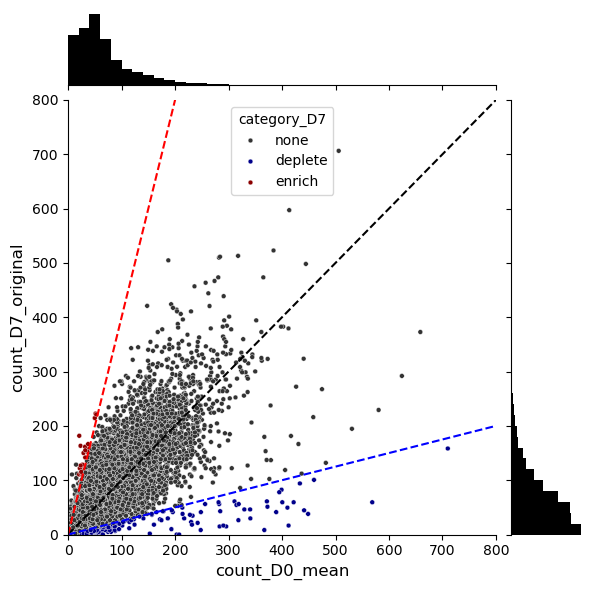

In [43]:
color_palette = ["#333333","#00008B","#8B0000"]
    
g = sns.JointGrid(data=sgRNA_count_df_CPM,x="count_D0_mean",y="count_D7_original")

g.ax_joint.set_xlim(0,800)
g.ax_joint.set_ylim(0,800)

sns.scatterplot(data=sgRNA_count_df_CPM,x="count_D0_mean",y="count_D7_original",
                hue="category_D7",palette=color_palette,s=12,color="black",ax=g.ax_joint)
g.ax_joint.plot((0,1000),(0,1000),linestyle="--",c="black")
g.ax_joint.plot((0,1000),(0,250),linestyle="--",c="blue")
g.ax_joint.plot((0,250),(0,1000),linestyle="--",c="red")

binrange = np.arange(0,800,20)
g.ax_marg_x.hist(sgRNA_count_df_CPM["count_D0_mean"],
                 bins=binrange, color="black")
g.ax_marg_y.hist(sgRNA_count_df_CPM["count_D7_original"],
                 bins=binrange, color="black", orientation="horizontal")

plt.savefig("Figure_joint_D0_D7.pdf")

In [44]:
gene_name,gene_count = \
    np.unique(sgRNA_count_df_CPM[sgRNA_count_df_CPM["category_D7"]=="deplete"]["target_gene"],
              return_counts=True)
print(sgRNA_count_df_CPM[sgRNA_count_df_CPM["category_D7"]=="deplete"].shape[0])
print("deplete",gene_name[gene_count>2])

gene_name,gene_count = \
    np.unique(sgRNA_count_df_CPM[sgRNA_count_df_CPM["category_D7"]=="enrich"]["target_gene"],
              return_counts=True)
print(sgRNA_count_df_CPM[sgRNA_count_df_CPM["category_D7"]=="enrich"].shape[0])
print("enrich",gene_name[gene_count>2])

380
deplete ['FOXP1' 'GATA4' 'GATA6' 'HAND2' 'ISL1' 'MESP1' 'NKX2-5' 'TBX5'
 'non-targeting']
27
enrich []


### Compare D0 and scRNA_lib

/tmp/ipykernel_33398/912847940.py:6: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(data=sgRNA_count_df_CPM,x="count_D0_mean",y="scRNA_count",


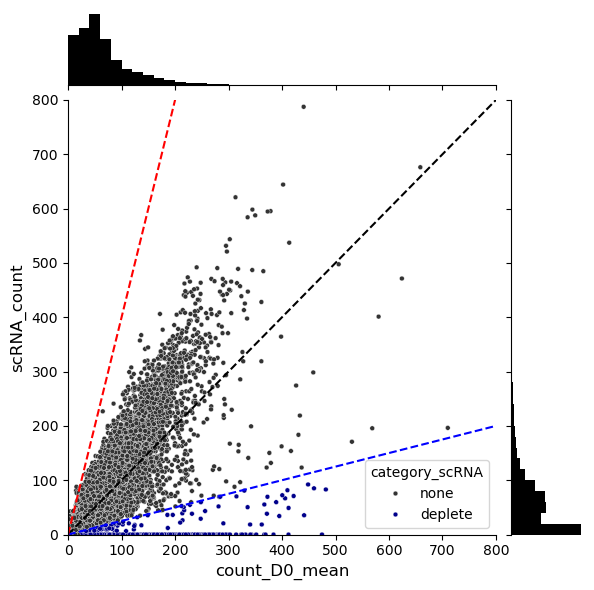

In [45]:
g = sns.JointGrid(data=sgRNA_count_df_CPM,x="count_D0_mean",y="scRNA_count")

g.ax_joint.set_xlim(0,800)
g.ax_joint.set_ylim(0,800)

sns.scatterplot(data=sgRNA_count_df_CPM,x="count_D0_mean",y="scRNA_count",
                hue="category_scRNA",palette=color_palette,s=12,color="black",ax=g.ax_joint)
g.ax_joint.plot((0,1000),(0,1000),linestyle="--",c="black")
g.ax_joint.plot((0,1000),(0,250),linestyle="--",c="blue")
g.ax_joint.plot((0,250),(0,1000),linestyle="--",c="red")

binrange = np.arange(0,800,20)
g.ax_marg_x.hist(sgRNA_count_df_CPM["count_D0_mean"],
                 bins=binrange, color="black")
g.ax_marg_y.hist(sgRNA_count_df_CPM["scRNA_count"],
                 bins=binrange, color="black", orientation="horizontal")

plt.savefig("Figure_joint_D0_scRNA.pdf")

In [46]:
gene_name,gene_count = \
    np.unique(sgRNA_count_df_CPM[sgRNA_count_df_CPM["category_scRNA"]=="deplete"]["target_gene"],
              return_counts=True)
print(sgRNA_count_df_CPM[sgRNA_count_df_CPM["category_scRNA"]=="deplete"].shape[0])
print("deplete",gene_name[gene_count>4])

gene_name,gene_count = \
    np.unique(sgRNA_count_df_CPM[sgRNA_count_df_CPM["category_scRNA"]=="enrich"]["target_gene"],
              return_counts=True)

print("enrich",gene_name[gene_count>4])

1410
deplete ['APITD1-CORT' 'CBFA2T3' 'CBFB' 'CGGBP1' 'CPEB1' 'EBF4' 'FOXK2' 'FOXP1'
 'GATA4' 'GATA6' 'GLI2' 'HDGF' 'IRX6' 'ISL1' 'KLF10' 'MEF2BNB-MEF2B'
 'MSANTD3' 'MSLN' 'NCOA3' 'NFATC3' 'NFE4' 'NFKB1' 'NKX2-5' 'OR2C3'
 'POU2F3' 'PRDM11' 'PURG' 'RELB' 'SCRT1' 'SCXA' 'TBX5' 'TEAD3' 'TFDP1'
 'ZNF20' 'ZNF273' 'ZNF540' 'ZNF592' 'ZSCAN31' 'chrUn' 'non-targeting']
0
enrich []


In [50]:
sgRNA_count_df_CPM.to_csv("./Full_dropout_analysis.csv")

### Systematic analysis

In [47]:
# test_count_list = ["count_D0_repA","count_D0_repB","count_D7_original","scRNA_count"]
# corr_matrix = pd.DataFrame(index=test_count_list,columns=test_count_list)
# combis = combinations(range(4),2)

# for index1 in range(4):
#     for index2 in range(4):
#         corr_p = stats.pearsonr(sgRNA_count_df_CPM[test_count_list[index1]],
#                                 sgRNA_count_df_CPM[test_count_list[index2]]).statistic
#         corr_p = round(corr_p,3)
#         corr_matrix.at[test_count_list[index1],test_count_list[index2]] = corr_p

# corr_matrix = corr_matrix.fillna(0)
# sns.heatmap(corr_matrix,vmin=0,vmax=1)


/tmp/ipykernel_33398/3514690370.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  corr_matrix = corr_matrix.fillna(0)


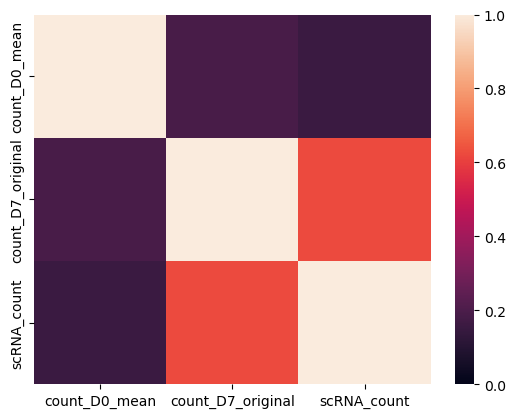

In [48]:
test_count_list = ["count_D0_mean","count_D7_original","scRNA_count"]
corr_matrix = pd.DataFrame(index=test_count_list,columns=test_count_list)
combis = combinations(range(len(test_count_list)),2)

for index1 in range(len(test_count_list)):
    for index2 in range(len(test_count_list)):
        corr_p = stats.pearsonr(sgRNA_count_df_CPM[test_count_list[index1]],
                                sgRNA_count_df_CPM[test_count_list[index2]]).statistic
        corr_p = round(corr_p,3)
        corr_matrix.at[test_count_list[index1],test_count_list[index2]] = corr_p

corr_matrix = corr_matrix.fillna(0)
sns.heatmap(corr_matrix,vmin=0,vmax=1)
plt.savefig("Figure_heat_3timepoint.pdf")

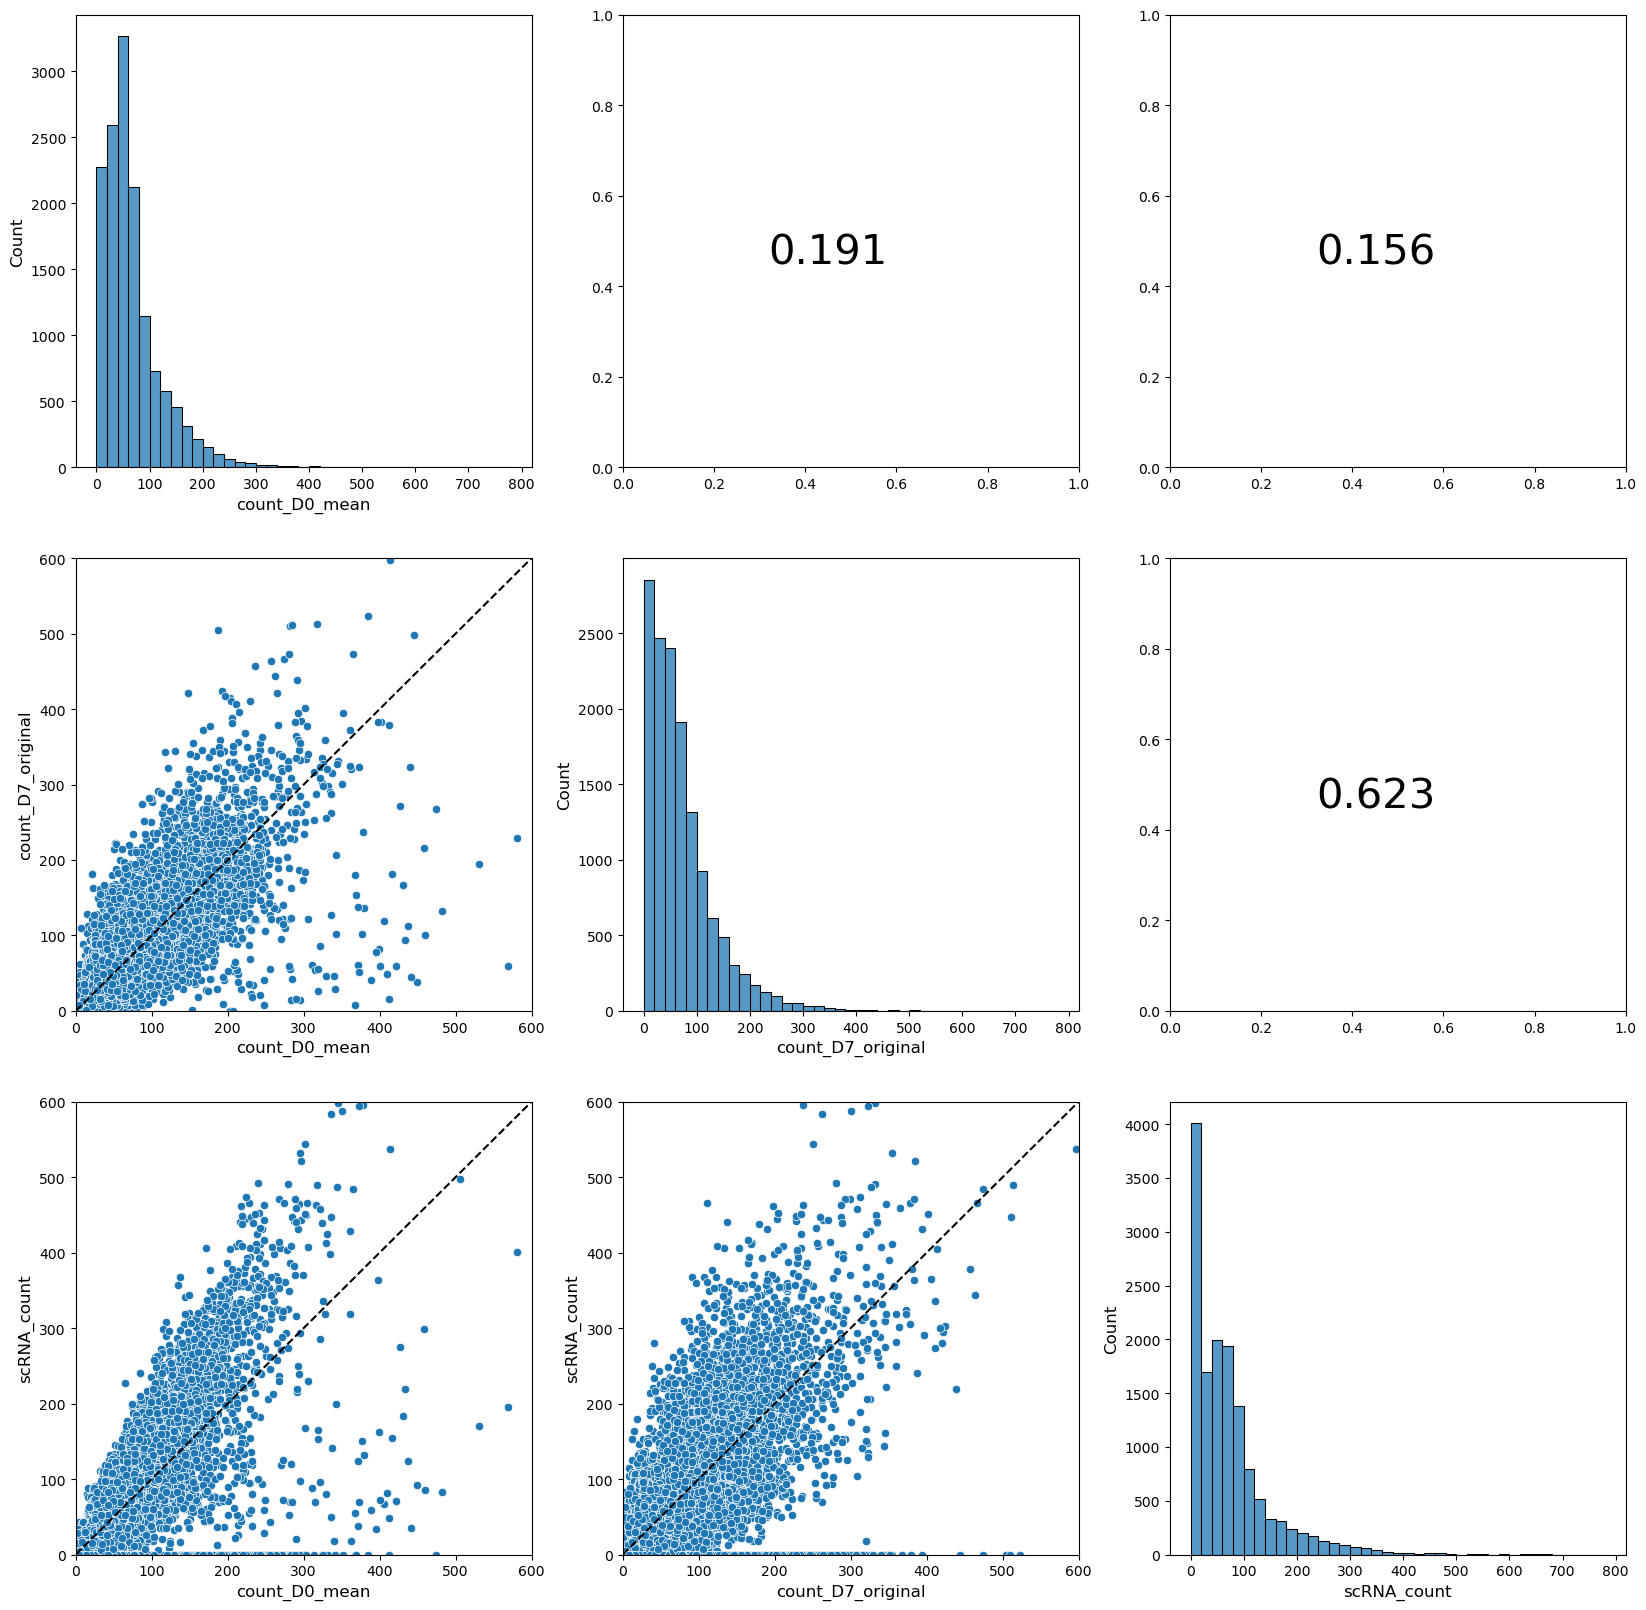

In [49]:
test_count_list = ["count_D0_mean","count_D7_original","scRNA_count"]
fig,ax = plt.subplots(len(test_count_list),len(test_count_list),figsize=(20,20))

combis = combinations(range(3),2)
binrange = np.arange(0,800,20)

for index in range(3):
    sns.histplot(data=sgRNA_count_df_CPM,
                 x=test_count_list[index],
                 ax=ax[index,index],bins=binrange)
    
for index1,index2 in combis:
    corr_p = stats.pearsonr(sgRNA_count_df_CPM[test_count_list[index1]],
                            sgRNA_count_df_CPM[test_count_list[index2]]).statistic
    corr_p = round(corr_p,3)
    ax[index1,index2].set_xlim(0,1)
    ax[index1,index2].set_ylim(0,1)
    ax[index1,index2].text(0.32,0.45,corr_p,{"size":30})
    
    ax[index2,index1].set_xlim(0,600)
    ax[index2,index1].set_ylim(0,600)
    sns.scatterplot(data=sgRNA_count_df_CPM,
                    x=test_count_list[index1],y=test_count_list[index2],
                    ax=ax[index2,index1]
                   )
    ax[index2,index1].plot((0,3000),(0,3000),linestyle="--",c="black")

plt.savefig("Figure_scatter_hist_3timepoint.pdf")